Dataset wav files conversion into log-mel spectrograms

In [ ]:
import os
import random
import shutil
import requests
import zipfile
from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split

def download_and_prepare_speech_commands(
    output_dir="data",
    target_classes=("yes", "no", "up", "down"),
    unknown_classes_count=10,
    seed=42,
    zip_output=True,
    clean=True
):
    """
    Downloads Google Speech Commands dataset, extracts selected classes,
    samples `unknown_classes_count` other classes as 'unknown',
    splits into train/val/test (70/15/15),
    and optionally saves as a zip.
    """
    url = "http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz"
    archive_path = "speech_commands_v0.02.tar.gz"
    extracted_path = "speech_commands"

    random.seed(seed)
    os.makedirs(output_dir, exist_ok=True)

    # Step 1: Download dataset if not already present
    if not os.path.exists(archive_path):
        print("Downloading dataset...")
        response = requests.get(url, stream=True)
        total_size = int(response.headers.get('content-length', 0))
        with open(archive_path, 'wb') as f, tqdm(
            desc=archive_path,
            total=total_size,
            unit='iB',
            unit_scale=True,
            unit_divisor=1024,
        ) as bar:
            for data in response.iter_content(chunk_size=1024):
                size = f.write(data)
                bar.update(size)

    # Step 2: Extract if not already extracted
    if not os.path.exists(extracted_path):
        print("Extracting dataset...")
        shutil.unpack_archive(archive_path, extracted_path)

    # Step 3: Collect target classes + sample unknown classes
    all_classes = [d.name for d in Path(extracted_path).iterdir() if d.is_dir()]
    available_classes = set(all_classes) - set(target_classes)

    if len(available_classes) < unknown_classes_count:
        raise ValueError("Not enough remaining classes to sample unknowns.")

    unknown_classes = random.sample(list(available_classes), unknown_classes_count)

    print(f"Target classes: {target_classes}")
    print(f"Unknown classes (mapped to 'unknown'): {unknown_classes}")

    # Step 4: Gather file lists
    class_to_files = {}
    for cls in target_classes:
        class_to_files[cls] = list((Path(extracted_path) / cls).glob("*.wav"))

    unknown_files = []
    for cls in unknown_classes:
        unknown_files.extend(list((Path(extracted_path) / cls).glob("*.wav")))
    class_to_files["unknown"] = unknown_files

    # Step 5: Train/val/test split (70/15/15)
    splits = {}
    for cls, files in class_to_files.items():
        train, temp = train_test_split(files, test_size=0.30, random_state=seed)  # 70% train, 30% left
        val, test = train_test_split(temp, test_size=0.50, random_state=seed)   # 15% val, 15% test
        splits[cls] = {"train": train, "val": val, "test": test}

    # Step 6: Copy files into structured folders
    for cls, split_dict in splits.items():
        for split, files in split_dict.items():
            out_dir = Path(output_dir) / split / cls
            out_dir.mkdir(parents=True, exist_ok=True)
            for f in files:
                shutil.copy(f, out_dir / f.name)

    # Step 7: Zip the dataset
    if zip_output:
        zip_path = f"{output_dir}.zip"
        print(f"Creating zip archive at {zip_path}...")
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, _, files in os.walk(output_dir):
                for file in files:
                    file_path = os.path.join(root, file)
                    arcname = os.path.relpath(file_path, output_dir)
                    zipf.write(file_path, arcname)
        print(f"Zipped dataset saved as: {zip_path}")
    # Step 8: Cleanup
    if clean:
        print("Cleaning up intermediate files to free memory...")
        if os.path.exists(extracted_path):
            shutil.rmtree(extracted_path)
        if os.path.exists(output_dir):
            shutil.rmtree(output_dir)
        if os.path.exists(archive_path):
            os.remove(archive_path)
        print("Cleanup complete. Only final zip kept.")
    # Summary
    print("\nSummary:")
    for cls, split_dict in splits.items():
        print(f"{cls:8s} -> Train: {len(split_dict['train'])}, Val: {len(split_dict['val'])}, Test: {len(split_dict['test'])}")
    
    
download_and_prepare_speech_commands()

Target classes: ('yes', 'no', 'up', 'down')
Unknown classes (mapped to 'unknown'): ['tree', 'wow', 'learn', 'six', 'cat', 'two', 'bird', 'bed', 'right', 'forward']
Creating zip archive at data.zip...
Zipped dataset saved as: data.zip
Cleaning up intermediate files to free memory...
Cleanup complete. Only final zip kept.

Summary:
yes      -> Train: 2830, Val: 607, Test: 607
no       -> Train: 2758, Val: 591, Test: 592
up       -> Train: 2606, Val: 558, Test: 559
down     -> Train: 2741, Val: 588, Test: 588
unknown  -> Train: 17248, Val: 3696, Test: 3697


In [5]:
import zipfile
import io
import os
import numpy as np
import librosa
import soundfile as sf
import tempfile
from tqdm import tqdm
import warnings

# === Silence noisy warnings from librosa ===
warnings.filterwarnings("ignore", category=UserWarning, module="librosa")
warnings.filterwarnings("ignore", category=FutureWarning, module="librosa")

# === Constants (matching C implementation) ===
SAMPLE_RATE = 16000
FRAME_DUR = 0.032
FRAME_SIZE = int(SAMPLE_RATE * FRAME_DUR)  # 512
FRAME_STRIDE_DUR = 0.024
FRAME_STRIDE = int(SAMPLE_RATE * FRAME_STRIDE_DUR)  # 384
NUM_BINS = FRAME_SIZE // 2  # 256
FILTER_NUMBER = 40
MIN_FREQ = 0
MAX_FREQ = SAMPLE_RATE // 2  # 8000
COEFFICIENT = 0.96875
NOISE_FLOOR = -40.0
SEGMENT_SEC = 1.0

# === C-style implementation functions ===
def pre_emphasis(audio):
    """Pre-emphasis matching C implementation"""
    emphasized = np.zeros_like(audio, dtype=np.float32)
    emphasized[0] = audio[0] / 32768.0
    for i in range(1, len(audio)):
        emphasized[i] = (audio[i] / 32768.0) - COEFFICIENT * (audio[i-1] / 32768.0)
    return emphasized

def apply_windowing(frame):
    """Hamming window matching C implementation"""
    window = 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(len(frame)) / (len(frame) - 1))
    return frame * window

def hz_to_mel(hz):
    """Hz to Mel conversion matching C implementation"""
    return 1127.0 * np.log10(1 + hz / 700.0)

def mel_to_hz(mel):
    """Mel to Hz conversion matching C implementation"""
    return 700 * (10 ** (mel / 1127.0) - 1)

def create_mel_filterbank():
    """Create mel filterbank matching C implementation"""
    min_mel = hz_to_mel(MIN_FREQ)
    max_mel = hz_to_mel(MAX_FREQ)
    
    mel_points = np.zeros(FILTER_NUMBER + 2)
    mel_spacing = (max_mel - min_mel) / (FILTER_NUMBER + 1)
    for i in range(FILTER_NUMBER + 2):
        mel_points[i] = mel_to_hz(min_mel + i * mel_spacing)
        if mel_points[i] > MAX_FREQ:
            mel_points[i] = MAX_FREQ

    bin_indices = np.zeros(FILTER_NUMBER + 2, dtype=int)
    for i in range(FILTER_NUMBER + 2):
        bin_indices[i] = int(mel_points[i] * (NUM_BINS - 1) / (SAMPLE_RATE / 2.0))
        bin_indices[i] = max(0, min(NUM_BINS - 1, bin_indices[i]))

    filterbank = np.zeros((FILTER_NUMBER, NUM_BINS))

    for i in range(FILTER_NUMBER):
        left = bin_indices[i]
        middle = bin_indices[i+1]
        right = bin_indices[i+2]

        if left == middle:
            middle = min(left + 1, NUM_BINS - 1)
        if middle == right:
            right = min(middle + 1, NUM_BINS - 1)

        # Rising slope
        for j in range(left, middle):
            filterbank[i, j] = (j - left) / (middle - left)

        # Falling slope
        for j in range(middle, right):
            filterbank[i, j] = 1.0 - (j - middle) / (right - middle)
    
    return filterbank

def compute_spectrogram_c_style(audio_int16, target_frames=None):
    """
    Compute spectrogram using C-style implementation
    audio_int16: int16 audio samples
    target_frames: if specified, pad/truncate to this many frames
    """
    num_samples = len(audio_int16)
    
    # Calculate number of frames for 1 second (or available audio)
    total_duration = num_samples / SAMPLE_RATE
    num_frames_available = int((total_duration - FRAME_DUR) / FRAME_STRIDE_DUR) + 1
    
    # Use target_frames if specified, otherwise use available frames (max 42 for 1 second)
    if target_frames:
        num_frames = min(num_frames_available, target_frames)
    else:
        num_frames = min(num_frames_available, 42)  # ~1 second max
    
    # Pre-emphasis
    pre_emphasis_array = pre_emphasis(audio_int16)
    
    # Initialize spectrogram
    spectrogram = np.zeros((num_frames, NUM_BINS))

    # Frame processing
    for frame in range(num_frames):
        start = frame * FRAME_STRIDE
        end = start + FRAME_SIZE
        segment = pre_emphasis_array[start:end]
        
        # Pad if necessary
        if len(segment) < FRAME_SIZE:
            segment = np.pad(segment, (0, FRAME_SIZE - len(segment)))

        # Apply windowing
        windowed = apply_windowing(segment)
        
        # FFT
        fft = np.fft.rfft(windowed, n=FRAME_SIZE)
        magnitude = np.abs(fft)
        spectrogram[frame] = magnitude[:NUM_BINS]

    # Apply mel filterbank
    mel_filterbank = create_mel_filterbank()
    mel_spectrogram = np.dot(spectrogram, mel_filterbank.T)
    
    # Convert to log scale
    log_mel_spectrogram = 10 * np.log10(mel_spectrogram + 1e-20)

    # Apply noise floor and normalization (matching C implementation)
    log_mel_spectrogram = (log_mel_spectrogram - NOISE_FLOOR) / (-NOISE_FLOOR + 12)
    log_mel_spectrogram = np.clip(log_mel_spectrogram, 0, 1)
    
    # Quantization
    quantized = np.round(log_mel_spectrogram * 256) / 256.0
    
    # Hard threshold
    quantized = np.where(quantized >= 0.65, quantized, 0)
    
    # Pad or truncate to target_frames if specified
    if target_frames:
        if quantized.shape[0] < target_frames:
            quantized = np.pad(quantized, ((0, target_frames - quantized.shape[0]), (0, 0)))
        else:
            quantized = quantized[:target_frames]

    return quantized

# === Robust loader ===
def load_audio_from_zip(z, fname, target_sr=16000):
    try:
        with z.open(fname) as file_data:
            wav_bytes = io.BytesIO(file_data.read())

            try:
                # First try with soundfile
                y, sr = sf.read(wav_bytes, dtype="float32")
            except Exception:
                # Fallback: audioread (via temp file)
                with tempfile.NamedTemporaryFile(suffix=".wav") as tmp:
                    tmp.write(wav_bytes.getbuffer())
                    tmp.flush()
                    y, sr = librosa.load(tmp.name, sr=None)

            # Resample if needed
            if sr != target_sr:
                y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
                sr = target_sr

            return np.asarray(y, dtype=np.float32), sr

    except Exception as e:
        print(f"[WARN] Skipping {fname} due to error: {e}")
        return None, None

# === MFE Extraction using C-style implementation ===
def extract_mfe_segments_c_style(y, sr, segment_sec=SEGMENT_SEC, target_frames=None):
    """Extract MFE segments using C-style implementation"""
    max_val = np.max(np.abs(y))
    if max_val == 0 or not np.isfinite(max_val):
        return []
    
    # Normalize to [-1, 1] range
    y = y / max_val
    if not np.all(np.isfinite(y)):
        return []
    
    # Convert to int16 format (as expected by C-style implementation)
    y_int16 = (y * 32767).astype(np.int16)
    
    mfe_segments = []
    segment_samples = int(segment_sec * sr)
    
    for start_idx in range(0, len(y_int16), segment_samples):
        end_idx = start_idx + segment_samples
        if end_idx > len(y_int16):
            # For the last segment, take what's available
            segment = y_int16[start_idx:]
            if len(segment) < segment_samples // 2:  # Skip very short segments
                break
        else:
            segment = y_int16[start_idx:end_idx]

        # Compute spectrogram using C-style implementation
        mfe = compute_spectrogram_c_style(segment, target_frames=target_frames)
        mfe_segments.append(mfe)

    return mfe_segments

# === Main processing from ZIP ===
def process_zip_dataset(zip_path, output_path, segment_sec=1.0, target_frames=None, clean=False):
    samples = []
    labels = []
    label_map = {}
    skipped = 0

    with zipfile.ZipFile(zip_path, "r") as z:
        wav_files = [
            f for f in z.namelist() 
            if f.lower().endswith(".wav") and "__macosx" not in f.lower()
        ]

        for f in tqdm(wav_files, desc="Processing WAVs"):
            # Label = parent folder name
            parts = f.split("/")
            if len(parts) >= 2:
                label = parts[-2]
            else:
                label = "unknown"

            if label not in label_map:
                label_map[label] = len(label_map)

            # Load audio
            y, sr = load_audio_from_zip(z, f, target_sr=SAMPLE_RATE)
            if y is None:
                skipped += 1
                continue

            # Extract features using C-style implementation
            mfe_segments = extract_mfe_segments_c_style(y, sr, segment_sec=segment_sec, target_frames=target_frames)

            for mfe in mfe_segments:
                samples.append(mfe)
                labels.append(label_map[label])

    # Convert to numpy arrays
    samples = np.array(samples, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    # Save
    np.savez_compressed(
        output_path,
        features=samples,
        labels=labels,
        label_map=label_map
    )

    if clean:
        print("Cleaning up intermediate files to free memory...")
        if os.path.exists(zip_path):
            os.remove(zip_path)
        print("Cleanup complete. Only final zip kept.")
    
    print("\n" + "="*50)
    print("PROCESSING DETAILED SUMMARY")
    print("="*50)
    print(f"Total WAV files found    : {len(wav_files)}")
    print(f"Total files processed    : {len(wav_files) - skipped}")
    print(f"Total files skipped      : {skipped}")
    print(f"Total valid segments     : {len(samples)}")
    print(f"Classes found            : {len(label_map)}")
    print(f"Label map                : {label_map}")
    print(f"Feature shape            : {samples.shape if len(samples) > 0 else 'N/A'}")
    print(f"\nSaved dataset: {output_path}")
    print("="*50)

# === Run ===
if __name__ == "__main__":
    process_zip_dataset(
        zip_path="data.zip",
        output_path="dataset_kws_multi.npz",
        segment_sec=1.0,
        target_frames=40,  
        clean=True
    )

Processing WAVs: 100%|██████████| 27653/27653 [40:06<00:00, 11.49it/s]  


Cleaning up intermediate files to free memory...
Cleanup complete. Only final zip kept.

PROCESSING DETAILED SUMMARY
Total WAV files found    : 27653
Total files processed    : 27653
Total files skipped      : 0
Total valid segments     : 27583
Classes found            : 5
Label map                : {'no': 0, 'up': 1, 'down': 2, 'unknown': 3, 'yes': 4}
Feature shape            : (27583, 40, 40)

Saved dataset: dataset_kws_multi.npz


Dataset extraction for training

In [1]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 1. Set random seed
seed = 22
tf.random.set_seed(seed)
np.random.seed(seed)

def debug_data_distribution(X_train, y_train, X_val, y_val, X_test, y_test):
    """Debug function to check data distribution and potential issues."""
    print("\n" + "="*60)
    print("DATA DISTRIBUTION ANALYSIS")
    print("="*60)

    # Class distribution
    print("Class distribution:")
    print(f"Train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Val:   {dict(zip(*np.unique(y_val, return_counts=True)))}")
    print(f"Test:  {dict(zip(*np.unique(y_test, return_counts=True)))}")

    # Value ranges
    print(f"\nData value ranges:")
    print(f"Train: min={X_train.min():.4f}, max={X_train.max():.4f}, mean={X_train.mean():.4f}")
    print(f"Val:   min={X_val.min():.4f}, max={X_val.max():.4f}, mean={X_val.mean():.4f}")
    print(f"Test:  min={X_test.min():.4f}, max={X_test.max():.4f}, mean={X_test.mean():.4f}")

    # Shapes
    print(f"\nData shapes:")
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # Mean activations
    train_mean = X_train.mean(axis=(1,2,3))
    val_mean = X_val.mean(axis=(1,2,3))
    print(f"\nMean activation per sample:")
    print(f"Train mean: {train_mean.mean():.4f} ± {train_mean.std():.4f}")
    print(f"Val mean:   {val_mean.mean():.4f} ± {val_mean.std():.4f}")

    # Warnings
    if len(np.unique(y_val)) != len(np.unique(y_train)):
        print("⚠️ WARNING: Validation set doesn't contain all classes!")

    if X_val.std() == 0 or X_train.std() == 0:
        print("⚠️ WARNING: Zero std detected - check your data!")

    if abs(X_train.mean() - X_val.mean()) > 0.5:
        print("⚠️ WARNING: Large mean difference between train/val sets!")

    print("="*60)

def create_balanced_dataset(shape_input, file="dataset_kws_multi.npz",
                           values_name='features', labels_name='labels'):
    """
    Load dataset and balance classes.
    balance_strategy = 'undersample' or 'oversample'
    """
    if len(shape_input) == 3:
        height, width, channels = shape_input
    elif len(shape_input) == 2:
        height, width = shape_input
        channels = 1
    else:
        raise ValueError("Shape Input must be (h, w) or (h, w, c).")

    # Load
    dataset = np.load(file)
    samples = dataset[values_name][:, :height, :width]
    classes = dataset[labels_name].astype(int)
    unique_classes = np.unique(classes)

    print(f"Original dataset: {samples.shape}, classes: {unique_classes}")
    print(f"Original class distribution: {dict(zip(*np.unique(classes, return_counts=True)))}")
    # Split
    X_temp, X_test, y_temp, y_test = train_test_split(
        samples, classes, test_size=0.2, stratify=classes, random_state=seed
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=seed
    )

    if channels == 1:
        X_train = np.expand_dims(X_train, -1)
        X_val = np.expand_dims(X_val, -1)
        X_test = np.expand_dims(X_test, -1)

    # Debug
    debug_data_distribution(X_train, y_train, X_val, y_val, X_test, y_test)

    return X_train, y_train, X_val, y_val, X_test, y_test, len(unique_classes)

# === Example usage ===
shape_input = (40, 40, 1)
X_train, y_train, X_val, y_val, X_test, y_test, n_classes = create_balanced_dataset(
    shape_input
)
print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_val:", np.unique(y_val))
print("Unique values in y_test:", np.unique(y_test))
X_train=X_train.reshape(X_train.shape[0], -1)
X_val=X_val.reshape(X_val.shape[0], -1)
X_test=X_test.reshape(X_test.shape[0], -1)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
class_names=['no', 'up', 'down', 'unknown', 'yes']


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Original dataset: (27583, 40, 40), classes: [0 1 2 3 4]
Original class distribution: {0: 3929, 1: 3715, 2: 3908, 3: 11994, 4: 4037}

DATA DISTRIBUTION ANALYSIS
Class distribution:
Train: {0: 2357, 1: 2229, 2: 2345, 3: 7196, 4: 2422}
Val:   {0: 786, 1: 743, 2: 781, 3: 2399, 4: 808}
Test:  {0: 786, 1: 743, 2: 782, 3: 2399, 4: 807}

Data value ranges:
Train: min=0.0000, max=1.0000, mean=0.2987
Val:   min=0.0000, max=1.0000, mean=0.2994
Test:  min=0.0000, max=1.0000, mean=0.2991

Data shapes:
Train: (16549, 40, 40, 1), Val: (5517, 40, 40, 1), Test: (5517, 40, 40, 1)

Mean activation per sample:
Train mean: 0.2987 ± 0.1436
Val mean:   0.2994 ± 0.1442
Unique values in y_train: [0 1 2 3 4]
Unique values in y_val: [0 1 2 3 4]
Unique values in y_test: [0 1 2 3 4]
Train: (16549, 1600), Val: (5517, 1600), Test: (5517, 1600)


2025-09-05 18:53:24.756637: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-09-05 18:53:24.756858: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-09-05 18:53:24.756887: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-09-05 18:53:24.757134: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-05 18:53:24.757158: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "kws_dense_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,725 (2.07 MB)

 Trainable params: 542,725 (2.07 MB)

...

2025-09-05 18:53:26.056621: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2525 - f1_score: 0.2467 - loss: 6.2373
Epoch 1: val_f1_score improved from None to 0.27461, saving model to best_f1_model.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.2667 - f1_score: 0.2615 - loss: 7.1965 - val_accuracy: 0.3150 - val_f1_score: 0.2746 - val_loss: 3.6429 - learning_rate: 0.0010
Epoch 2/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3012 - f1_score: 0.3003 - loss: 6.6549
Epoch 2: val_f1_score did not improve from 0.27461
518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.2937 - f1_score: 0.2919 - loss: 10.5639 - val_accuracy: 0.2418 - val_f1_score: 0.2289 - val_loss: 32.4988 - learning_rate: 0.0010
Epoch 3/100
517/518 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2779 - f1_score: 0.2691 - loss: 62.6183
Epoch 3: val_f1_score improved from 0.27461 to 0.32401, saving model to best_f1_model.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.2751 - f1_score: 0.2702 - loss: 115.9454 - val_accuracy: 0.3583 - val_f1_score: 0.3240 - val_loss: 290.6952 - learning_rate: 0.0010
Epoch 4/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2839 - f1_score: 0.2780 - loss: 443.3184
Epoch 4: val_f1_score did not improve from 0.32401
518/518 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.2809 - f1_score: 0.2771 - loss: 599.4100 - val_accuracy: 0.3085 - val_f1_score: 0.2750 - val_loss: 992.4051 - learning_rate: 0.0010
Epoch 5/100
517/518 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2907 - f1_score: 0.2884 - loss: 1127.6433
Epoch 5: val_f1_score did not improve from 0.32401
518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.2928 - f1_score: 0.2912 - loss: 1376.4335 - val_accuracy: 0.2895 - val_f1_score: 0.2724 - val_loss: 1842.7201 - learning_rate: 0.0010
Epoch 6/100
517/518 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3075 - f1_score: 0.3054 - loss: 2173.0811


518/518 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.3282 - f1_score: 0.3341 - loss: 2958.4736 - val_accuracy: 0.3612 - val_f1_score: 0.3644 - val_loss: 1011.1990 - learning_rate: 2.0000e-04
Epoch 10/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3243 - f1_score: 0.3306 - loss: 1591.7985
Epoch 10: val_f1_score did not improve from 0.36443
518/518 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.3223 - f1_score: 0.3274 - loss: 1509.4919 - val_accuracy: 0.3348 - val_f1_score: 0.3166 - val_loss: 1260.2628 - learning_rate: 2.0000e-04
Epoch 11/100
517/518 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3085 - f1_score: 0.3135 - loss: 1249.9504
Epoch 11: val_f1_score did not improve from 0.36443
518/518 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.3041 - f1_score: 0.3085 - loss: 1247.7262 - val_accuracy: 0.3109 - val_f1_score: 0.3120 - val_loss: 1279.7086 - learning_rate: 2.0000e-04
Epoch 12/100
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2996 - f1_score: 0.3

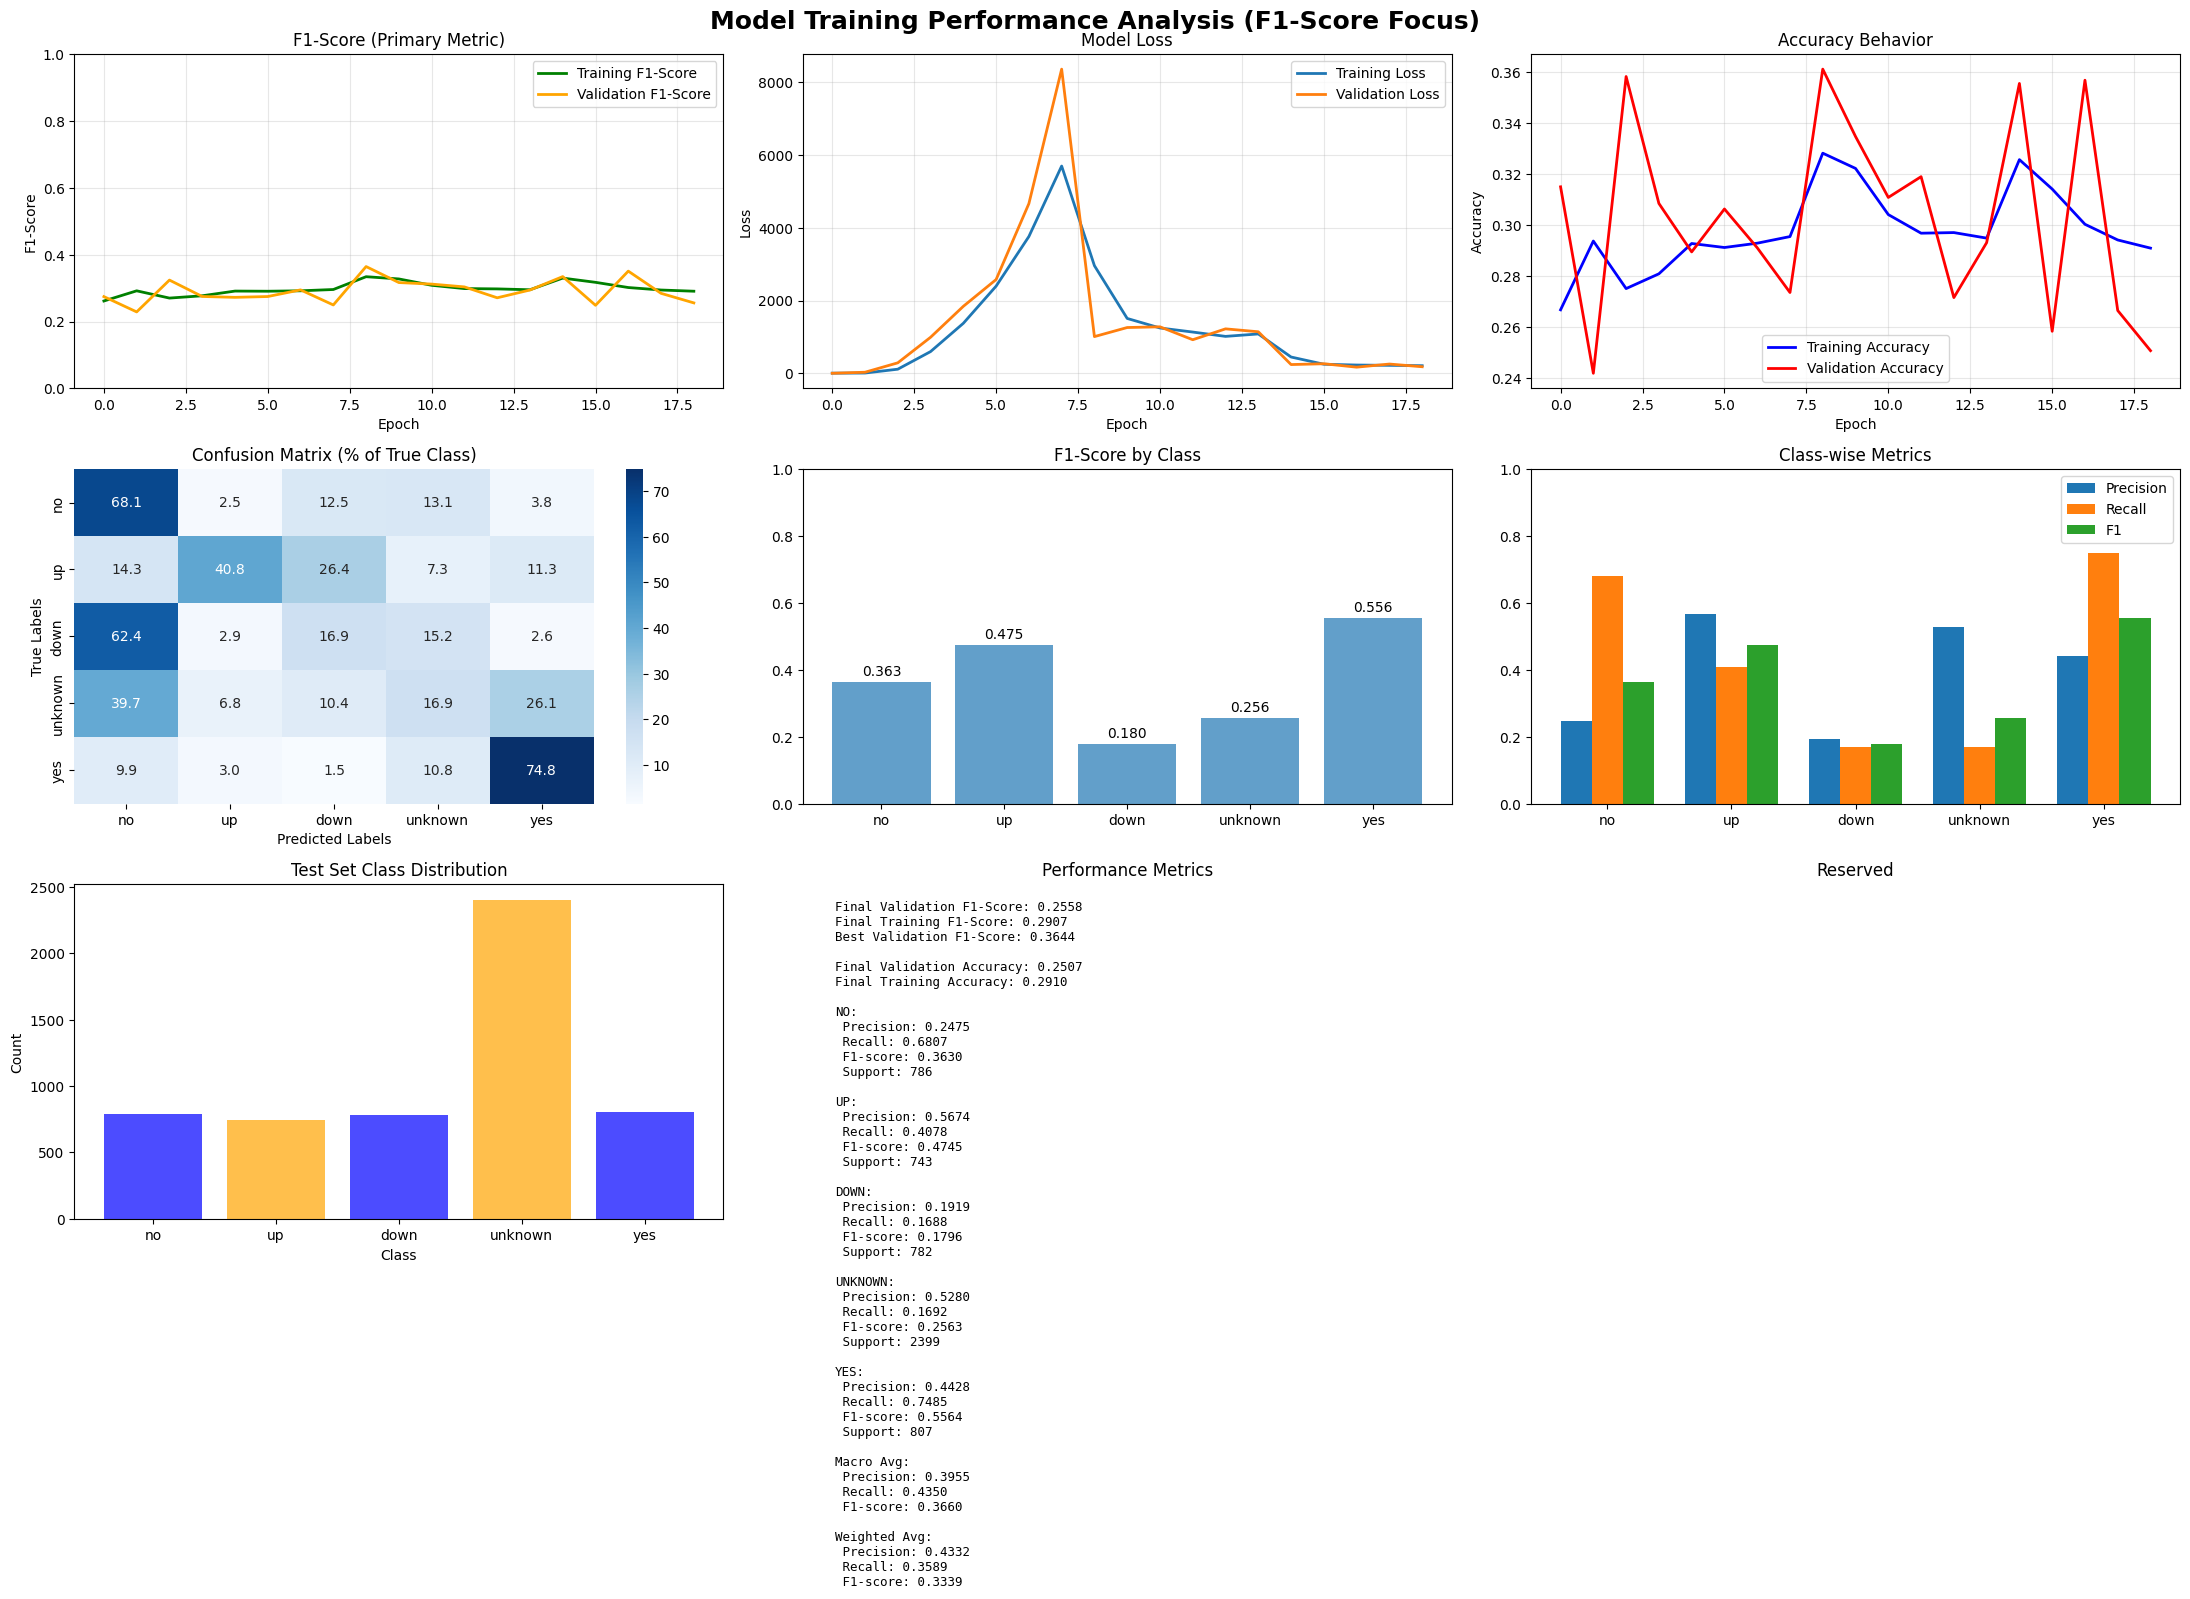

TRAINING SUMMARY (F1-Score Focus)
Total epochs trained: 19
Final training F1-score: 0.2907
Final validation F1-score: 0.2558
Best validation F1-score: 0.3644
Final training accuracy: 0.2910
Final validation accuracy: 0.2507
Final training loss: 212.1029
Final validation loss: 183.3266

Test Set Performance:
              precision    recall  f1-score   support

          no       0.25      0.68      0.36       786
          up       0.57      0.41      0.47       743
        down       0.19      0.17      0.18       782
     unknown       0.53      0.17      0.26      2399
         yes       0.44      0.75      0.56       807

    accuracy                           0.36      5517
   macro avg       0.40      0.43      0.37      5517
weighted avg       0.43      0.36      0.33      5517


Overall Weighted F1-Score on Test Set: 0.3339
Model saved as 'kws_multi_cnn_model.h5'


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

class F1Score(tf.keras.metrics.Metric):
    def __init__(self, num_classes, average="macro", name="f1_score", **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.average = average

        # Store per-class statistics
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros")
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros")
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert predictions and labels to class indices
        y_pred = tf.argmax(y_pred, axis=1)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)

        # One-hot encode labels for per-class calculations
        y_true_oh = tf.one_hot(y_true, depth=self.num_classes)
        y_pred_oh = tf.one_hot(y_pred, depth=self.num_classes)

        tp = tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        fp = tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0)
        fn = tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0)

        self.tp.assign_add(tf.cast(tp, self.tp.dtype))
        self.fp.assign_add(tf.cast(fp, self.fp.dtype))
        self.fn.assign_add(tf.cast(fn, self.fn.dtype))

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall = self.tp / (self.tp + self.fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)

        if self.average == "macro":
            return tf.reduce_mean(f1)
        elif self.average == "weighted":
            weights = self.tp + self.fn
            return tf.reduce_sum(f1 * weights) / (tf.reduce_sum(weights) + 1e-7)
        else:  # "none" → return vector of per-class F1s
            return f1

    def reset_state(self):
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))


def create_sparse_friendly_cnn(input_shape, num_classes):
    """CNN for keyword spotting with BatchNorm"""
    inputs = tf.keras.Input(shape=input_shape, name="input")
    
    # Conv block 1
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    # Conv block 2
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    # Conv block 3
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)

    # Flatten + Dense
    x = layers.Flatten()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="teacher_kws_cnn")
    
    # Use F1-score as primary metric
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy', F1Score(n_classes)]
    )
    return model

def build_student_model(input_shape, num_classes):
    """Your exact target architecture - simple 3-layer dense network"""
    inputs = tf.keras.Input(shape=input_shape, name="input")  # Already flattened input (1600,)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_1")(inputs)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_2")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Dense(256, activation="relu", name="dense_3")(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="kws_dense_model")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy', F1Score(n_classes)]
    )
    return model

def calculate_precision_recall_f1(y_true, y_pred, class_names):
    """Calculate precision, recall, and F1 for each class"""
    from sklearn.metrics import precision_recall_fscore_support
    
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    
    results = {}
    for i, class_name in enumerate(class_names):
        results[class_name] = {
            'precision': precision[i],
            'recall': recall[i],
            'f1': f1[i],
            'support': support[i]
        }
    
    return results

def plot_training_performance(history, model, X_test, y_test, class_names, y_train=None, y_val=None, y_test_labels=None):
    """Create comprehensive graphs showing training performance with F1-score, accuracy, and sample counts"""

    # Get predictions
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Convert one-hot encoded y_test to class indices if needed
    if len(y_test.shape) > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test
    
    # Calculate precision, recall, F1 for each class
    metrics = calculate_precision_recall_f1(y_true, y_pred, class_names)
    
    # Create figure with more subplots (3x3 grid now)
    fig, axes = plt.subplots(3, 3, figsize=(22, 16))
    fig.suptitle('Model Training Performance Analysis (F1-Score Focus)', fontsize=18, fontweight='bold')
    
    # 1. F1-Score plot
    if 'f1_score' in history.history:
        axes[0, 0].plot(history.history['f1_score'], label='Training F1-Score', linewidth=2, color='green')
        axes[0, 0].plot(history.history['val_f1_score'], label='Validation F1-Score', linewidth=2, color='orange')
        axes[0, 0].set_title('F1-Score (Primary Metric)')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('F1-Score')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].set_ylim(0, 1)

    # 2. Loss plot
    axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Accuracy plot
    axes[0, 2].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 2].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 2].set_title('Accuracy Behavior')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix (% of True Class)')
    axes[1, 0].set_xlabel('Predicted Labels')
    axes[1, 0].set_ylabel('True Labels')
    
    # 5. F1-Score by class
    class_f1_scores = [metrics[c]['f1'] for c in class_names]
    bars = axes[1, 1].bar(range(len(class_names)), class_f1_scores, alpha=0.7)
    axes[1, 1].set_title('F1-Score by Class')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_xticks(range(len(class_names)))
    axes[1, 1].set_xticklabels(class_names)
    for bar, value in zip(bars, class_f1_scores):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom')
    
    # 6. Precision-Recall-F1 grouped bars
    precision_values = [metrics[c]['precision'] for c in class_names]
    recall_values = [metrics[c]['recall'] for c in class_names]
    f1_values = [metrics[c]['f1'] for c in class_names]
    width = 0.25
    idx = np.arange(len(class_names))
    axes[1, 2].bar(idx - width, precision_values, width, label="Precision")
    axes[1, 2].bar(idx, recall_values, width, label="Recall")
    axes[1, 2].bar(idx + width, f1_values, width, label="F1")
    axes[1, 2].set_title('Class-wise Metrics')
    axes[1, 2].set_xticks(idx)
    axes[1, 2].set_xticklabels(class_names)
    axes[1, 2].legend()
    axes[1, 2].set_ylim(0, 1)
    
    # 7. Sample counts (stacked)
    unique, counts = np.unique(y_true, return_counts=True)
    axes[2, 0].bar(unique, counts, color=['blue', 'orange'], alpha=0.7)
    axes[2, 0].set_title('Test Set Class Distribution')
    axes[2, 0].set_xlabel('Class')
    axes[2, 0].set_ylabel('Count')
    axes[2, 0].set_xticks(unique)
    axes[2, 0].set_xticklabels(class_names)
    
    # 8. Text metrics summary
    metrics_text = ""
    if 'val_f1_score' in history.history: 
        metrics_text += f"Final Validation F1-Score: {history.history['val_f1_score'][-1]:.4f}\n" 
        metrics_text += f"Final Training F1-Score: {history.history['f1_score'][-1]:.4f}\n" 
        metrics_text += f"Best Validation F1-Score: {max(history.history['val_f1_score']):.4f}\n\n" 
    metrics_text += f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}\n" 
    metrics_text += f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}\n\n" 
    
    for c in class_names: 
        metrics_text += f"{c.upper()}:\n" 
        metrics_text += f" Precision: {metrics[c]['precision']:.4f}\n" 
        metrics_text += f" Recall: {metrics[c]['recall']:.4f}\n" 
        metrics_text += f" F1-score: {metrics[c]['f1']:.4f}\n" 
        metrics_text += f" Support: {metrics[c]['support']}\n\n" 

    # Macro/weighted
    macro_precision = np.mean([metrics[c]['precision'] for c in class_names]) 
    macro_recall = np.mean([metrics[c]['recall'] for c in class_names]) 
    macro_f1 = np.mean([metrics[c]['f1'] for c in class_names]) 
    total_support = sum([metrics[c]['support'] for c in class_names]) 
    weighted_precision = sum([metrics[c]['precision'] * metrics[c]['support'] for c in class_names]) / total_support 
    weighted_recall = sum([metrics[c]['recall'] * metrics[c]['support'] for c in class_names]) / total_support 
    weighted_f1 = sum([metrics[c]['f1'] * metrics[c]['support'] for c in class_names]) / total_support 
    
    metrics_text += f"Macro Avg:\n Precision: {macro_precision:.4f}\n Recall: {macro_recall:.4f}\n F1-score: {macro_f1:.4f}\n\n"
    metrics_text += f"Weighted Avg:\n Precision: {weighted_precision:.4f}\n Recall: {weighted_recall:.4f}\n F1-score: {weighted_f1:.4f}" 
    
    axes[2, 1].text(0.05, 0.95, metrics_text, transform=axes[2, 1].transAxes, 
                    fontfamily='monospace', verticalalignment='top', fontsize=9) 
    axes[2, 1].set_title('Performance Metrics') 
    axes[2, 1].set_axis_off()
    
    # 9. Reserved slot
    axes[2, 2].axis("off")
    axes[2, 2].set_title("Reserved")
    
    plt.tight_layout()
    plt.show()
    
    # Print training summary with F1-score focus
    print("=" * 60)
    print("TRAINING SUMMARY (F1-Score Focus)")
    print("=" * 60)
    print(f"Total epochs trained: {len(history.history['loss'])}")
    if 'f1_score' in history.history:
        print(f"Final training F1-score: {history.history['f1_score'][-1]:.4f}")
        print(f"Final validation F1-score: {history.history['val_f1_score'][-1]:.4f}")
        print(f"Best validation F1-score: {max(history.history['val_f1_score']):.4f}")
    print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Final training loss: {history.history['loss'][-1]:.4f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")
    
    print("\nTest Set Performance:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Calculate and display overall F1-score
    overall_f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\nOverall Weighted F1-Score on Test Set: {overall_f1:.4f}")
    
    return fig

def main():
    # Model with F1-score monitoring
    model = build_student_model((1600,), n_classes)
    #model = create_sparse_friendly_cnn((40, 40, 1), n_classes)
    model.summary()
    
    # Enhanced callbacks with F1-score monitoring
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_f1_score', patience=10, restore_best_weights=True, 
            mode='max', verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_f1_score', factor=0.2, patience=5, min_lr=1e-6, 
            mode='max', verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            'best_f1_model.h5', monitor='val_f1_score',
            save_best_only=True, mode='max', verbose=1)
    ]

    # Train with class weights
    class_weights = compute_class_weight('balanced', 
                                   classes=np.unique(y_train), 
                                   y=y_train)
    class_weight_dict = dict(enumerate(class_weights))
    
    print("Training with F1-score monitoring...")
    print(f"Class weights: {class_weight_dict}")
    
    history = model.fit(
         X_train, y_train,
         epochs=100, batch_size=32,
         validation_data=(X_val, y_val),
         class_weight=class_weight_dict,
         callbacks=callbacks, verbose=1
    )
    
    plot_training_performance(history, model, X_test, y_test, class_names, y_test_labels=class_names)

    # Save model
    model.save('kws_multi_dense_model.h5')
    print("Model saved as 'kws_multi_cnn_model.h5'")

if __name__ == "__main__":
    main()